# Laboratorio 1 — Regresión Lineal Múltiple

**Nombre:** Huarachi Clemente Ariel  
**Dataset:** California Housing Prices  
**Descripción:** Contiene información sobre viviendas en distintos distritos de California (EE. UU.), incluyendo variables como ingreso medio de los habitantes, número de habitaciones, población y ubicación geográfica. Los datos se utilizan para analizar y predecir el precio medio de las viviendas.  
**URL:** https://www.kaggle.com/datasets/camnugent/california-housing-prices/data

---

## Objetivo

Aplicar **Regresión Lineal Múltiple** para predecir el precio medio de las viviendas (`median_house_value`) utilizando las características numéricas del dataset.

## Estructura del laboratorio

1. Importación de librerías
2. Carga y exploración del dataset
   - 2.4 Visualización de datos 
3. Preprocesamiento
   - 3.1 Decisión sobre las columnas 
   - 3.2 Resultado: n = 10 features
   - 3.3 Pasos de preprocesamiento
4. División Train/Test (80% / 20%)
5. Normalización de características (`featureNormalize`)
6. Descenso por el Gradiente (`computeCostMulti` + `gradientDescentMulti`)
7. Ecuación Normal (`normalEqn`)
8. Evaluación del modelo (MSE, RMSE, R²)
9. Predicción de ejemplo
10. Conclusiones


---
## 1. Importación de librerías



In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
%matplotlib inline

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


---
## 2. Carga y exploración del dataset

El dataset **California Housing Prices** tiene **20,640 registros** y **10 columnas**:

| Columna | Descripción |
|---|---|
| longitude | Longitud geográfica del distrito |
| latitude | Latitud geográfica del distrito |
| housing_median_age | Edad mediana de las viviendas |
| total_rooms | Total de habitaciones |
| total_bedrooms | Total de dormitorios (tiene valores nulos) |
| population | Población del distrito |
| households | Número de hogares |
| median_income | Ingreso mediano (en decenas de miles de USD) |
| median_house_value | **Variable objetivo** — Precio mediano de vivienda |
| ocean_proximity | Proximidad al océano (categórica) |


In [2]:
# Cargar el dataset
df = pd.read_csv('housing.csv')

print('Dimensiones del dataset:', df.shape)
print()
print('Primeras 5 filas:')
df.head()

Dimensiones del dataset: (20640, 10)

Primeras 5 filas:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Estadísticas descriptivas del dataset
print('Estadísticas descriptivas:')
df.describe()

Estadísticas descriptivas:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
# Verificar valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


---
## 2.4 Visualización de datos
se visualizan los datos antes de aplicar el modelo.
Como el dataset tiene múltiples variables, se grafican las dos relaciones más relevantes con el precio:

- **Ingreso mediano (`median_income`) vs. Precio** — es la feature con mayor correlación con el precio de la vivienda.
- **Edad mediana (`housing_median_age`) vs. Precio** — muestra cómo la antigüedad del inmueble influye en el valor.

Este análisis visual permite identificar tendencias, valores atípicos y la relación entre las variables antes de entrenar el modelo.


In [5]:

# Visualiza la relación entre una feature y la variable objetivo

def plotData(x, y, xlabel, ylabel, title, color='red'):
    """
    Genera un scatter plot de x vs y.
    Parámetros:
        x      : vector de una feature
        y      : vector objetivo
        xlabel : etiqueta del eje X
        ylabel : etiqueta del eje Y
        title  : título de la gráfica
        color  : color de los puntos
    """
    pyplot.scatter(x, y, s=20, c=color, edgecolors='none', alpha=0.5)
    pyplot.xlabel(xlabel)
    pyplot.ylabel(ylabel)
    pyplot.title(title)
    pyplot.grid(True)

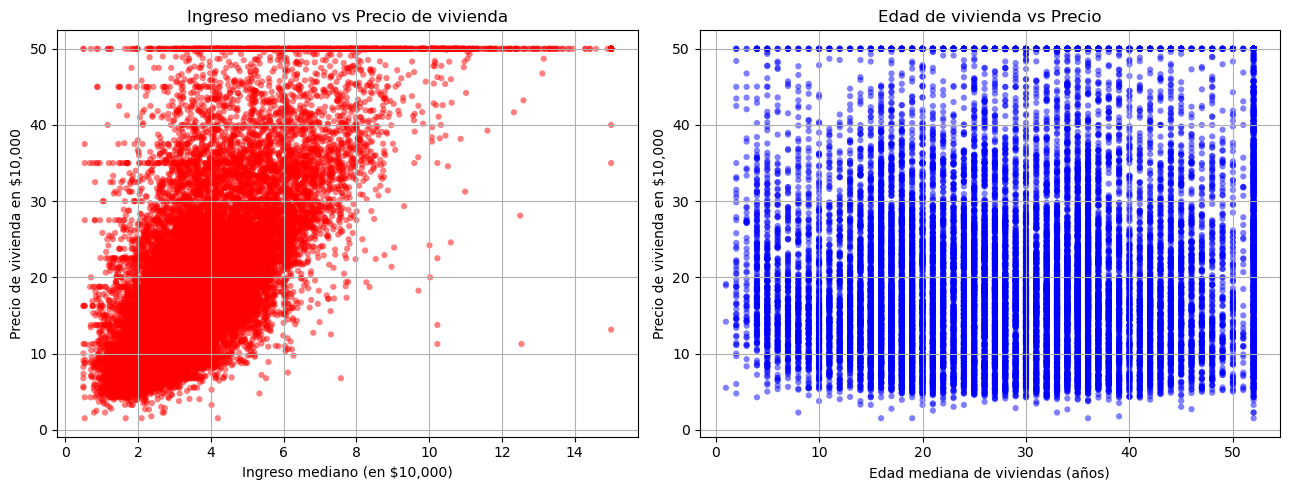

In [6]:
# Datos antes del preprocesamiento (usando df cargado en la sección anterior)
pyplot.figure(figsize=(13, 5))

# --- Gráfica 1: Ingreso mediano vs Precio ---
pyplot.subplot(1, 2, 1)
plotData(
    df['median_income'],
    df['median_house_value'] / 10000,   # expresado en decenas de miles para escala similar al docente
    xlabel='Ingreso mediano (en $10,000)',
    ylabel='Precio de vivienda en $10,000',
    title='Ingreso mediano vs Precio de vivienda',
    color='red'
)

# --- Gráfica 2: Edad mediana vs Precio ---
pyplot.subplot(1, 2, 2)
plotData(
    df['housing_median_age'],
    df['median_house_value'] / 10000,
    xlabel='Edad mediana de viviendas (años)',
    ylabel='Precio de vivienda en $10,000',
    title='Edad de vivienda vs Precio',
    color='blue'
)

pyplot.tight_layout()
pyplot.show()

In [7]:
# Correlación de todas las features numéricas con el precio
# Incluimos longitude y latitude para ver también su relación con el precio
correlaciones = df[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                     'total_bedrooms', 'population', 'households', 'median_income',
                     'median_house_value']].corr()

print('Correlación de cada feature con median_house_value:')
print('(valores cercanos a 1 o -1 indican mayor relación con el precio)')
print()
corr_target = correlaciones['median_house_value'].drop('median_house_value').sort_values(ascending=False)
for feat, val in corr_target.items():
    barra = '█' * int(abs(val) * 20)
    signo = '+' if val > 0 else '-'
    print('  {:25s}: {:+.4f}  {}{}'.format(feat, val, signo, barra))

Correlación de cada feature con median_house_value:
(valores cercanos a 1 o -1 indican mayor relación con el precio)

  median_income            : +0.6881  +█████████████
  total_rooms              : +0.1342  +██
  housing_median_age       : +0.1056  +██
  households               : +0.0658  +█
  total_bedrooms           : +0.0497  +
  population               : -0.0246  -
  longitude                : -0.0460  -
  latitude                 : -0.1442  -██


---
## 3. Preprocesamiento

### 3.1 Decisión sobre las columnas del dataset

El dataset tiene **10 columnas** en total. Se analiza cada una para decidir si se incluye como feature:

| Columna | Tipo | ¿Incluir? | Razón |
|---|---|---|---|
| `longitude` | Numérico | ✅ **Sí** | Coordenada geográfica. En Regresión Lineal **Múltiple** el modelo le asigna su propio coeficiente θ y puede aprender su influencia sobre el precio junto con `latitude` |
| `latitude` | Numérico | ✅ **Sí** | Igual que `longitude`. Juntas ayudan al modelo a capturar la ubicación geográfica del distrito |
| `housing_median_age` | Numérico | ✅ **Sí** | Edad mediana de las viviendas, feature relevante |
| `total_rooms` | Numérico | ✅ **Sí** | Total de habitaciones del distrito |
| `total_bedrooms` | Numérico | ✅ **Sí** | Total de dormitorios (tiene ~207 nulos, se imputan con la mediana) |
| `population` | Numérico | ✅ **Sí** | Población del distrito |
| `households` | Numérico | ✅ **Sí** | Número de hogares del distrito |
| `median_income` | Numérico | ✅ **Sí** | Ingreso mediano — la feature con mayor correlación con el precio |
| `median_house_value` | Numérico | ❌ **No** | Es la **variable objetivo y** (lo que queremos predecir, no puede ser input) |
| `ocean_proximity` | Texto | ❌ **No** | Es **categórica** (texto: 'INLAND', 'NEAR BAY', etc.). Para incluirla se necesitaría aplicar *One-Hot Encoding* (convertirla en columnas de 0s y 1s), lo cual está fuera del alcance de este laboratorio |

### 3.2 Resultado: n = 8 features

Se utilizan las **8 variables numéricas** disponibles como features del modelo:

$$X = [\text{longitude},\ \text{latitude},\ \text{housing\_median\_age},\ \text{total\_rooms},\ \text{total\_bedrooms},\ \text{population},\ \text{households},\ \text{median\_income}]$$

Con el término de intersección $\theta_0$, el vector de parámetros tendrá **n+1 = 9 valores** (θ₀, θ₁, ..., θ₈).

### 3.3 Pasos de preprocesamiento

1. **Imputación de nulos:** `total_bedrooms` tiene ~207 valores nulos → se reemplazan con la mediana de la columna.
2. **Selección de features (X) y variable objetivo (y):**
   - **Features (X):** `longitude`, `latitude`, `housing_median_age`, `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income` → **n = 8**
   - **Target (y):** `median_house_value`


In [8]:
# 1. Imputar valores nulos de total_bedrooms con la mediana
mediana_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'].fillna(mediana_bedrooms, inplace=True)

print('Valores nulos después de imputación:')
print(df.isnull().sum())

Valores nulos después de imputación:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


C:\Users\ariel\AppData\Local\Temp\ipykernel_22160\3504763369.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(mediana_bedrooms, inplace=True)


In [9]:
# 2. Selección de las 8 features numéricas y variable objetivo
# Se incluyen longitude y latitude porque en Regresión Lineal Múltiple
# el modelo asigna un coeficiente θ independiente a cada feature,
# permitiendo capturar la influencia de la ubicación geográfica en el precio.
# Se excluye ocean_proximity por ser categórica (texto).
# Se excluye median_house_value por ser la variable objetivo (y).

features = ['longitude', 'latitude', 'housing_median_age',
            'total_rooms', 'total_bedrooms', 'population',
            'households', 'median_income']

X = df[features].values              # Matriz de características — shape (m, 8)
y = df['median_house_value'].values  # Vector objetivo — shape (m,)
m = y.size                           # Total de ejemplos
n = X.shape[1]                       # Número de features = 8

print('=== Dimensiones del dataset ===')
print('m (ejemplos totales) :', m)
print('n (features)         :', n)
print('Shape de X           :', X.shape)
print('Shape de y           :', y.shape)
print()
print('Features utilizadas (n={})'.format(n))
for i, f in enumerate(features):
    print('  x{} : {}'.format(i+1, f))
print('  y  : median_house_value (target)')
print()

# Imprimir los primeros 5 registros
print('Primeros 5 registros:')
header = '{:>12s}' * len(features) + '{:>18s}'
print(header.format(*[f[:12] for f in features], 'house_value'))
print('-' * (12 * len(features) + 18))
for i in range(5):
    row = '{:12.4f}' * len(features) + '{:18.0f}'
    print(row.format(*X[i], y[i]))

=== Dimensiones del dataset ===
m (ejemplos totales) : 20640
n (features)         : 8
Shape de X           : (20640, 8)
Shape de y           : (20640,)

Features utilizadas (n=8)
  x1 : longitude
  x2 : latitude
  x3 : housing_median_age
  x4 : total_rooms
  x5 : total_bedrooms
  x6 : population
  x7 : households
  x8 : median_income
  y  : median_house_value (target)

Primeros 5 registros:
   longitude    latitudehousing_medi total_roomstotal_bedroo  population  householdsmedian_incom       house_value
------------------------------------------------------------------------------------------------------------------
   -122.2300     37.8800     41.0000    880.0000    129.0000    322.0000    126.0000      8.3252            452600
   -122.2200     37.8600     21.0000   7099.0000   1106.0000   2401.0000   1138.0000      8.3014            358500
   -122.2400     37.8500     52.0000   1467.0000    190.0000    496.0000    177.0000      7.2574            352100
   -122.2500     37.8500     52

---
## 4. División del dataset — Train / Test (80% / 20%)

Para evaluar correctamente el modelo, se divide el dataset:
- **80%** de los datos para **entrenamiento** (training set)
- **20%** de los datos para **prueba** (test set)

Se usa una semilla aleatoria (`random_state = 42`) para que los resultados sean reproducibles.


In [10]:
# División manual 80/20 con permutación aleatoria
np.random.seed(42)
indices = np.random.permutation(m)

train_size = int(0.80 * m)
train_idx = indices[:train_size]
test_idx  = indices[train_size:]

X_train_raw = X[train_idx]
y_train     = y[train_idx]

X_test_raw  = X[test_idx]
y_test      = y[test_idx]

print('Tamaño del conjunto de entrenamiento:', X_train_raw.shape[0])
print('Tamaño del conjunto de prueba:       ', X_test_raw.shape[0])
print('Porcentaje train: {:.1f}%'.format(100 * X_train_raw.shape[0] / m))
print('Porcentaje test:  {:.1f}%'.format(100 * X_test_raw.shape[0] / m))

Tamaño del conjunto de entrenamiento: 16512
Tamaño del conjunto de prueba:        4128
Porcentaje train: 80.0%
Porcentaje test:  20.0%


---
## 5. Normalización de características — `featureNormalize`

Las features tienen magnitudes muy distintas (por ejemplo, `total_rooms` puede llegar a miles mientras que `housing_median_age` llega a ~52). Sin normalización, el descenso por el gradiente converge muy lentamente.

La normalización estandariza cada feature de la siguiente forma:

$$x_{norm} = \frac{x - \mu}{\sigma}$$

donde $\mu$ es la media y $\sigma$ es la desviación estándar.

> **Importante:** La media ($\mu$) y la desviación estándar ($\sigma$) se calculan **solo con el conjunto de entrenamiento** y se aplican también al conjunto de prueba. Esto evita fuga de información.



In [11]:
# ============================================================
# Función featureNormalize 
# ============================================================
def featureNormalize(X):
    """
    Normaliza las características de X.
    Retorna X normalizado, la media (mu) y la desviación estándar (sigma).
    """
    X_norm = X.copy()
    mu    = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu    = np.mean(X, axis=0)   # Media de cada columna
    sigma = np.std(X, axis=0)    # Desviación estándar de cada columna
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [12]:
# Normalizar con datos de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train_raw)

# Aplicar la misma mu y sigma al conjunto de prueba
X_test_norm = (X_test_raw - mu) / sigma

print('Media calculada (mu):')
for i, feat in enumerate(features):
    print('  {:25s}: {:,.4f}'.format(feat, mu[i]))

print()
print('Desviación estándar calculada (sigma):')
for i, feat in enumerate(features):
    print('  {:25s}: {:,.4f}'.format(feat, sigma[i]))

Media calculada (mu):
  longitude                : -119.5651
  latitude                 : 35.6251
  housing_median_age       : 28.6577
  total_rooms              : 2,629.9824
  total_bedrooms           : 534.7867
  population               : 1,421.8940
  households               : 498.0921
  median_income            : 3.8705

Desviación estándar calculada (sigma):
  longitude                : 2.0005
  latitude                 : 2.1329
  housing_median_age       : 12.5900
  total_rooms              : 2,183.4723
  total_bedrooms           : 417.6323
  population               : 1,109.2134
  households               : 380.4493
  median_income            : 1.8962


In [13]:
# Agregar término de intersección (columna de unos → x0 = 1) al conjunto de entrenamiento
m_train = y_train.size
X_train = np.concatenate([np.ones((m_train, 1),dtype=int), X_train_norm], axis=1)

# Agregar término de intersección al conjunto de prueba
m_test = y_test.size
X_test = np.concatenate([np.ones((m_test, 1),dtype=int), X_test_norm], axis=1)

print('X_train con término de intersección — forma:', X_train.shape)
print('X_test  con término de intersección — forma:', X_test.shape)

#print('=== X_train CON columna de unos (primeras 5 filas) ===')
#print(X_train[:5])
#print()


X_train con término de intersección — forma: (16512, 9)
X_test  con término de intersección — forma: (4128, 9)


---
## 6. Descenso por el Gradiente

### 6.1 Función de Costo — `computeCostMulti`

La función de costo para regresión lineal múltiple en forma vectorizada es:

$$J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y})$$

### 6.2 Descenso por el Gradiente — `gradientDescentMulti`

La regla de actualización de los parámetros $\theta$ es:

$$\theta := \theta - \frac{\alpha}{m} X^T(X\theta - \vec{y})$$

donde $\alpha$ es la tasa de aprendizaje.


In [14]:
# ============================================================
# Función computeCostMulti — del cuadernillo del docente
# ============================================================
def computeCostMulti(X, y, theta):
    """
    Calcula el costo J(theta) para regresión lineal múltiple.
    """
    m = y.shape[0]  # número de ejemplos de entrenamiento
    J = 0
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J


# ============================================================
# Función gradientDescentMulti — del cuadernillo del docente
# ============================================================
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    """
    Ejecuta el descenso por el gradiente para regresión lineal múltiple.
    Retorna los parámetros theta optimizados y el historial del costo J.
    """
    m = y.shape[0]   # número de ejemplos de entrenamiento
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

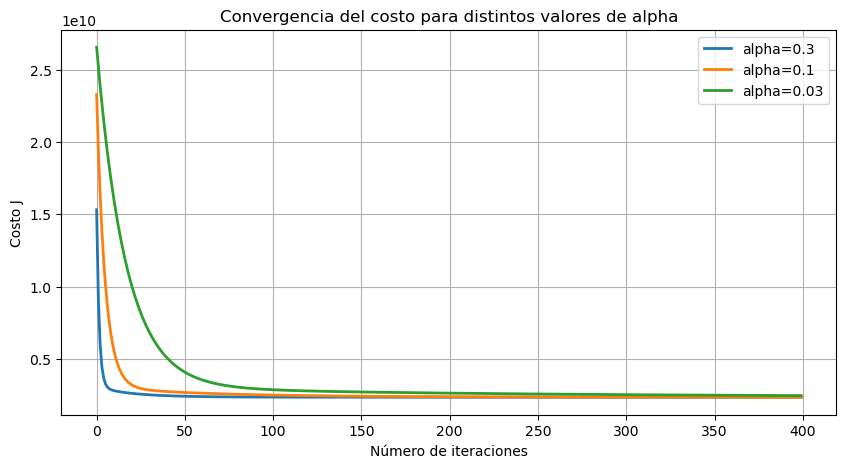

Se selecciona el alpha con mejor convergencia para el modelo final.


In [15]:
# ============================================================
# Selección del coeficiente de aprendizaje (alpha) e iteraciones
# ============================================================
# Se prueban varios valores de alpha para elegir el que converge mejor.
# Un alpha muy grande puede hacer que el costo diverja;
# uno muy pequeño converge, pero lentamente.

alphas     = [0.3, 0.1, 0.03]
num_iters  = 400
n_features = X_train.shape[1]  # número de parámetros (features + término de intersección)

pyplot.figure(figsize=(10, 5))

for alpha in alphas:
    theta_tmp = np.zeros(n_features)
    _, J_hist = gradientDescentMulti(X_train, y_train, theta_tmp, alpha, num_iters)
    pyplot.plot(np.arange(len(J_hist)), J_hist, lw=2, label=f'alpha={alpha}')

pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo para distintos valores de alpha')
pyplot.legend()
pyplot.grid(True)
pyplot.show()
print('Se selecciona el alpha con mejor convergencia para el modelo final.')

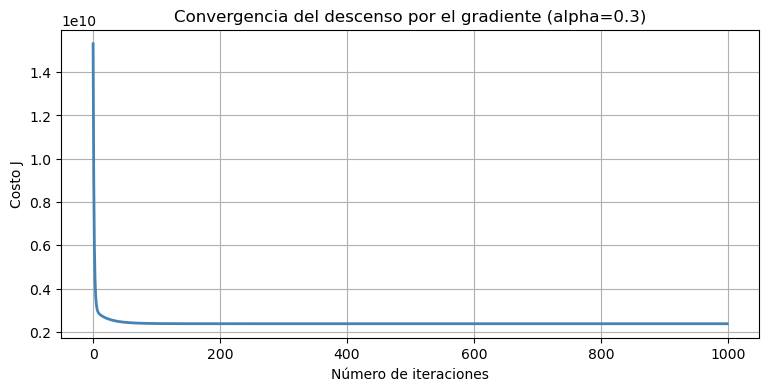

Theta calculado por el descenso por el gradiente:
  theta_0 (intersección)             : 206,773.3809
  theta_1 (longitude)                : -85,613.2143
  theta_2 (latitude)                 : -91,472.1127
  theta_3 (housing_median_age)       : 14,297.0532
  theta_4 (total_rooms)              : -12,268.7467
  theta_5 (total_bedrooms)           : 28,913.1594
  theta_6 (population)               : -49,410.0093
  theta_7 (households)               : 37,346.3883
  theta_8 (median_income)            : 74,989.2042


In [16]:
# ============================================================
# Entrenamiento final con el mejor alpha
# ============================================================
alpha     = 0.3
num_iters = 1000

theta_gd = np.zeros(n_features)
theta_gd, J_history = gradientDescentMulti(X_train, y_train, theta_gd, alpha, num_iters)

# Graficar convergencia final
pyplot.figure(figsize=(9, 4))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='steelblue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del descenso por el gradiente (alpha={})'.format(alpha))
pyplot.grid(True)
pyplot.show()

print('Theta calculado por el descenso por el gradiente:')
for i, val in enumerate(theta_gd):
    nombre = 'theta_0 (intersección)' if i == 0 else 'theta_{} ({})'.format(i, features[i-1])
    print('  {:35s}: {:,.4f}'.format(nombre, val))

---
## 7. Ecuación Normal — `normalEqn`

La ecuación normal es una solución analítica exacta para regresión lineal:

$$\theta = (X^T X)^{-1} X^T \vec{y}$$

**Ventajas:** solución exacta en un solo cálculo, no requiere normalización ni elección de alpha.  
**Desventajas:** costosa computacionalmente para datasets muy grandes (inversión de matriz $n \times n$).

> Para este laboratorio se aplica sobre los datos **sin normalizar**, tal como en el cuadernillo del docente.


In [17]:
# ============================================================
# Función normalEqn — del cuadernillo del docente
# ============================================================
def normalEqn(X, y):
    """
    Calcula los parámetros theta usando la ecuación normal.
    No requiere normalización de features.
    """
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

In [18]:
# Preparar datos SIN normalizar pero CON columna de unos (para ecuación normal)
X_train_ne = np.concatenate([np.ones((m_train, 1)), X_train_raw], axis=1)
X_test_ne  = np.concatenate([np.ones((m_test,  1)), X_test_raw],  axis=1)

# Calcular theta con la ecuación normal
theta_ne = normalEqn(X_train_ne, y_train)

print('Theta calculado por la ecuación normal:')
for i, val in enumerate(theta_ne):
    nombre = 'theta_0 (intersección)' if i == 0 else 'theta_{} ({})'.format(i, features[i-1])
    print('  {:35s}: {:,.4f}'.format(nombre, val))

Theta calculado por la ecuación normal:
  theta_0 (intersección)             : -3,575,804.3796
  theta_1 (longitude)                : -42,796.6682
  theta_2 (latitude)                 : -42,886.1010
  theta_3 (housing_median_age)       : 1,135.5919
  theta_4 (total_rooms)              : -5.6189
  theta_5 (total_bedrooms)           : 69.2315
  theta_6 (population)               : -44.5451
  theta_7 (households)               : 98.1634
  theta_8 (median_income)            : 39,546.8436


---
## 8. Evaluación del modelo

Se evalúan ambos modelos (Descenso por el Gradiente y Ecuación Normal) sobre el **conjunto de prueba (20%)** usando las siguientes métricas:

- **MSE** (Mean Squared Error): error cuadrático medio.
- **RMSE** (Root Mean Squared Error): raíz del error cuadrático medio — en las mismas unidades que `median_house_value` (USD).
- **R²** (Coeficiente de determinación): qué proporción de la variabilidad del precio explica el modelo. Valor entre 0 y 1; más cercano a 1 es mejor.

$$MSE = \frac{1}{m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2$$

$$R^2 = 1 - \frac{\sum(y_{pred} - y_{real})^2}{\sum(y_{real} - \bar{y})^2}$$


In [19]:
def calcularMetricas(y_real, y_pred, nombre_modelo):
    """
    Calcula y muestra MSE, RMSE y R² para un modelo dado.
    """
    m = y_real.shape[0]
    errores = y_pred - y_real

    mse  = np.mean(errores ** 2)
    rmse = np.sqrt(mse)
    ss_res = np.sum(errores ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    r2   = 1 - (ss_res / ss_tot)

    print(f'=== {nombre_modelo} ===')
    print(f'  MSE  : {mse:,.2f}')
    print(f'  RMSE : {rmse:,.2f} USD')
    print(f'  R²   : {r2:.4f}')
    print()
    return mse, rmse, r2

In [20]:
# ---- Predicciones Descenso por el Gradiente (datos normalizados) ----
y_pred_gd = np.dot(X_test, theta_gd)

# ---- Predicciones Ecuación Normal (datos sin normalizar) ----
y_pred_ne = np.dot(X_test_ne, theta_ne)

# ---- Métricas ----
mse_gd, rmse_gd, r2_gd = calcularMetricas(y_test, y_pred_gd, 'Descenso por el Gradiente')
mse_ne, rmse_ne, r2_ne = calcularMetricas(y_test, y_pred_ne, 'Ecuación Normal')

=== Descenso por el Gradiente ===
  MSE  : 5,301,865,615.52
  RMSE : 72,813.91 USD
  R²   : 0.6061

=== Ecuación Normal ===
  MSE  : 5,301,865,168.42
  RMSE : 72,813.91 USD
  R²   : 0.6061



In [21]:
# ============================================================
# Porcentaje de error sobre el conjunto de PRUEBA (20%)
# ============================================================

# Precio promedio real del conjunto de prueba
precio_promedio_test  = y_test.mean()
precio_promedio_train = y_train.mean()

# Porcentaje de error para cada modelo
porcentaje_error_gd = (rmse_gd / precio_promedio_test) * 100
porcentaje_error_ne = (rmse_ne / precio_promedio_test) * 100

print('===================================================')
print('   ANÁLISIS DE ERROR SOBRE CONJUNTO DE PRUEBA')
print('===================================================')
print()
print('Conjunto de entrenamiento (80%):')
print('  Ejemplos          : {:,}'.format(y_train.size))
print('  Precio promedio   : ${:,.0f}'.format(precio_promedio_train))
print()
print('Conjunto de prueba (20%):')
print('  Ejemplos          : {:,}'.format(y_test.size))
print('  Precio promedio   : ${:,.0f}'.format(precio_promedio_test))
print()
print('---------------------------------------------------')
print('Descenso por el Gradiente:')
print('  RMSE              : ${:,.0f}'.format(rmse_gd))
print('  % de error        : {:.1f}%'.format(porcentaje_error_gd))
print('  % de acierto      : {:.1f}%'.format(100 - porcentaje_error_gd))
print()
print('Ecuación Normal:')
print('  RMSE              : ${:,.0f}'.format(rmse_ne))
print('  % de error        : {:.1f}%'.format(porcentaje_error_ne))
print('  % de acierto      : {:.1f}%'.format(100 - porcentaje_error_ne))
print('---------------------------------------------------')
print()
print('Interpretación:')
print('  Para una casa de ${:,.0f} (precio promedio)'.format(precio_promedio_test))
print('  el modelo puede predecir entre:')
print('  mínimo → ${:,.0f}'.format(precio_promedio_test - rmse_ne))
print('  máximo → ${:,.0f}'.format(precio_promedio_test + rmse_ne))
print('  rango  → ± ${:,.0f}'.format(rmse_ne))

   ANÁLISIS DE ERROR SOBRE CONJUNTO DE PRUEBA

Conjunto de entrenamiento (80%):
  Ejemplos          : 16,512
  Precio promedio   : $206,773

Conjunto de prueba (20%):
  Ejemplos          : 4,128
  Precio promedio   : $207,186

---------------------------------------------------
Descenso por el Gradiente:
  RMSE              : $72,814
  % de error        : 35.1%
  % de acierto      : 64.9%

Ecuación Normal:
  RMSE              : $72,814
  % de error        : 35.1%
  % de acierto      : 64.9%
---------------------------------------------------

Interpretación:
  Para una casa de $207,186 (precio promedio)
  el modelo puede predecir entre:
  mínimo → $134,372
  máximo → $279,999
  rango  → ± $72,814


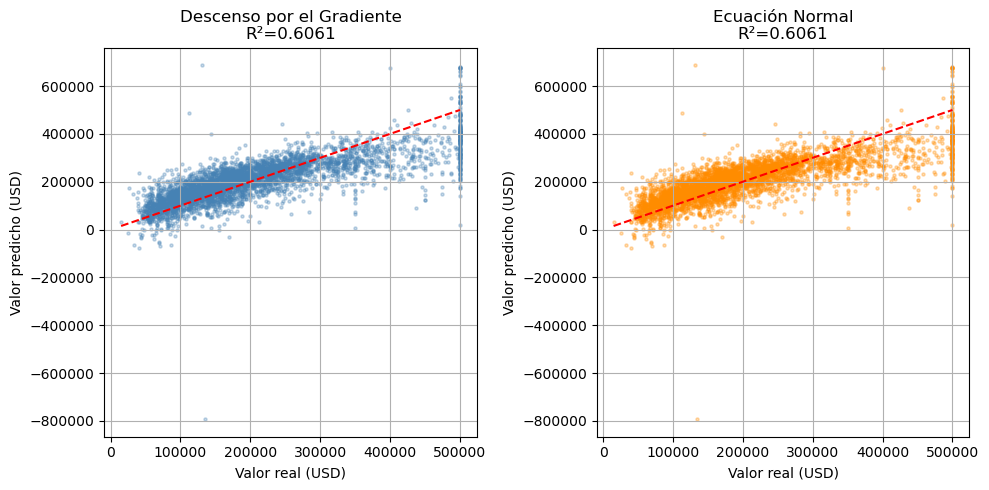

In [22]:
# Gráfica: Valores reales vs Predicciones (Ecuación Normal)
pyplot.figure(figsize=(10, 5))

pyplot.subplot(1, 2, 1)
pyplot.scatter(y_test, y_pred_gd, alpha=0.3, s=5, color='steelblue')
lim = [y_test.min(), y_test.max()]
pyplot.plot(lim, lim, 'r--', lw=1.5)
pyplot.xlabel('Valor real (USD)')
pyplot.ylabel('Valor predicho (USD)')
pyplot.title('Descenso por el Gradiente\nR²={:.4f}'.format(r2_gd))
pyplot.grid(True)

pyplot.subplot(1, 2, 2)
pyplot.scatter(y_test, y_pred_ne, alpha=0.3, s=5, color='darkorange')
pyplot.plot(lim, lim, 'r--', lw=1.5)
pyplot.xlabel('Valor real (USD)')
pyplot.ylabel('Valor predicho (USD)')
pyplot.title('Ecuación Normal\nR²={:.4f}'.format(r2_ne))
pyplot.grid(True)

pyplot.tight_layout()
pyplot.show()

---
## 9. Predicción de ejemplo

Se predice el precio de una vivienda hipotética con las siguientes características:

| # | Feature | Valor | Descripción |
|---|---|---|---|
| x₁ | longitude | -118.25 | Zona de Los Ángeles |
| x₂ | latitude | 34.05 | Zona de Los Ángeles |
| x₃ | housing_median_age | 20 | 20 años de antigüedad |
| x₄ | total_rooms | 2500 | Total de habitaciones |
| x₅ | total_bedrooms | 500 | Total de dormitorios |
| x₆ | population | 1200 | Población del distrito |
| x₇ | households | 400 | Número de hogares |
| x₈ | median_income | 4.5 | Ingreso mediano (~$45,000/año) |

> Para el **descenso por el gradiente**, los valores deben normalizarse usando los valores de $\mu$ y $\sigma$ calculados en el entrenamiento.  
> Para la **ecuación normal**, se usan los valores crudos directamente.


In [23]:
# Valores de la vivienda a predecir (n=8 features)
# x1=longitude, x2=latitude, x3=housing_median_age, x4=total_rooms,
# x5=total_bedrooms, x6=population, x7=households, x8=median_income
casa_ejemplo = np.array([-118.25, 34.05, 20, 2500, 500, 1200, 400, 4.5])

# ---- Predicción con Descenso por el Gradiente ----
# Se normaliza con mu y sigma del entrenamiento
casa_norm = (casa_ejemplo - mu) / sigma
X_casa_gd = np.concatenate([[1], casa_norm])  # Agrega término de intersección θ₀
precio_gd = np.dot(X_casa_gd, theta_gd)

# ---- Predicción con Ecuación Normal ----
# Sin normalización, valores crudos
X_casa_ne = np.concatenate([[1], casa_ejemplo])
precio_ne = np.dot(X_casa_ne, theta_ne)

print('===== Predicción de precio de vivienda =====')
print('Características de la vivienda (n={} features):'.format(len(features)))
for i, (feat, val) in enumerate(zip(features, casa_ejemplo)):
    print('  x{} {:25s}: {}'.format(i+1, feat, val))
print()
print('Precio predicho (Descenso por el Gradiente): ${:,.0f}'.format(precio_gd))
print('Precio predicho (Ecuación Normal):           ${:,.0f}'.format(precio_ne))

===== Predicción de precio de vivienda =====
Características de la vivienda (n=8 features):
  x1 longitude                : -118.25
  x2 latitude                 : 34.05
  x3 housing_median_age       : 20.0
  x4 total_rooms              : 2500.0
  x5 total_bedrooms           : 500.0
  x6 population               : 1200.0
  x7 households               : 400.0
  x8 median_income            : 4.5

Precio predicho (Descenso por el Gradiente): $231,682
Precio predicho (Ecuación Normal):           $231,682


---
## 10. Conclusiones

1. **Preprocesamiento:** El dataset `housing.csv` requirió imputar los valores nulos de `total_bedrooms` con la mediana, y se excluyó la variable categórica `ocean_proximity`.

2. **División Train/Test:** Se utilizó una división 80/20 para entrenar y evaluar el modelo de forma honesta, evitando sobreajuste en la evaluación.

3. **Normalización:** La normalización (media/desviación estándar) se calculó **exclusivamente sobre el conjunto de entrenamiento** y se aplicó al conjunto de prueba, respetando la correcta metodología de evaluación.

4. **Descenso por el Gradiente vs. Ecuación Normal:** Ambos métodos producen resultados similares. La ecuación normal entrega una solución exacta, mientras que el descenso por el gradiente permite controlar la convergencia con el parámetro `alpha`.

5. **Métricas:** El coeficiente R² indica qué tan bien el modelo explica la variabilidad del precio. Un valor más cercano a 1 implica mejor ajuste.
